## Logistic Regression for Imbalanced Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Generate and plot a synthetic imbalanced classification dataset
from collections import Counter
from sklearn.datasets import make_classification

In [3]:
## imbalanced dataset, weights = 0.90 is one class
X,y=make_classification(n_samples=10000,n_features=2,n_clusters_per_class=1,
                   n_redundant=0,weights=[0.99],random_state=10)

In [4]:
X

array([[ 1.87991016, -1.4850347 ],
       [ 0.37708311, -2.23858488],
       [ 1.35431163, -2.66463822],
       ...,
       [ 0.99509904, -0.54192355],
       [ 1.75859359, -1.54961188],
       [ 0.79770543, -1.99467372]], shape=(10000, 2))

In [5]:
Counter(y)

Counter({np.int64(0): 9846, np.int64(1): 154})

In [7]:
(154/(154+9846))*100

1.54

In [8]:
from sklearn.decomposition import PCA

<Axes: >

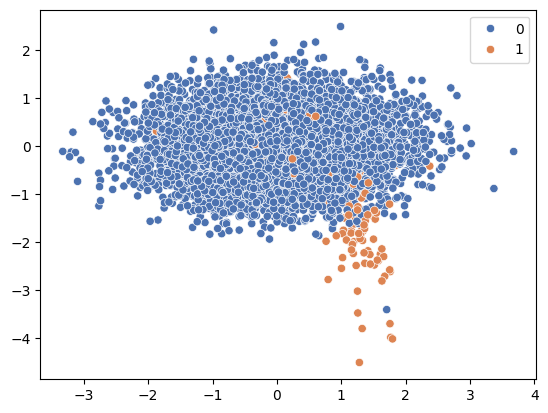

In [ ]:
pca = PCA()
pca.fit_transform(X)

sns.scatterplot(x= pca.fit_transform(X)[:,0], y =pca.fit_transform(X)[:,1], hue=y, palette= "deep")
##can see data is too low

## Splitting Data

In [12]:
## Split the dataset into train and test
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=100)

In [13]:
class_weight=[{0:w,1:y} for w in [0,1,10,50,100] for y in [0,1,10,50,100]]

In [14]:
class_weight

[{0: 0, 1: 0},
 {0: 0, 1: 1},
 {0: 0, 1: 10},
 {0: 0, 1: 50},
 {0: 0, 1: 100},
 {0: 1, 1: 0},
 {0: 1, 1: 1},
 {0: 1, 1: 10},
 {0: 1, 1: 50},
 {0: 1, 1: 100},
 {0: 10, 1: 0},
 {0: 10, 1: 1},
 {0: 10, 1: 10},
 {0: 10, 1: 50},
 {0: 10, 1: 100},
 {0: 50, 1: 0},
 {0: 50, 1: 1},
 {0: 50, 1: 10},
 {0: 50, 1: 50},
 {0: 50, 1: 100},
 {0: 100, 1: 0},
 {0: 100, 1: 1},
 {0: 100, 1: 10},
 {0: 100, 1: 50},
 {0: 100, 1: 100}]

## Basic Modelling

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, StratifiedKFold


In [32]:
from sklearn import metrics as m

In [34]:
model_b=LogisticRegression()
model_b.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [35]:
##Evaluations 
## All the scores can't be computed directly
y_pred_B = model_b.predict(X_test)

print(m.classification_report(y_test,y_pred_B))

print("Accuracy Score:",m.accuracy_score(y_test,y_pred_B))
print("Precision Score:",round(m.precision_score(y_test,y_pred_B,average='weighted'),2))
print("Recall Score:",round(m.recall_score(y_test,y_pred_B,average='weighted'),2))
print("F1 Score:",round(m.f1_score(y_test,y_pred_B,average='weighted'),2))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1964
           1       0.88      0.19      0.32        36

    accuracy                           0.98      2000
   macro avg       0.93      0.60      0.66      2000
weighted avg       0.98      0.98      0.98      2000

Accuracy Score: 0.985
Precision Score: 0.98
Recall Score: 0.98
F1 Score: 0.98


## GridSearchCV

In [21]:
param_grid = {
    'penalty': ['l2', 'l1','elasticnet'],
     'C' : [1.0,0,5,10,.05,100,50], 
     'solver': ['lbfgs', 'newton-cg', 'liblinear', 'newton-cholesky', 'sag', 'saga'],
     'n_jobs': [-1], 
     'l1_ratio': [1,0,.1,.8],
     'class_weight':class_weight
                  
    }

In [23]:
model=LogisticRegression()

grid_l = GridSearchCV(estimator=model,param_grid=param_grid,scoring="f1",cv= StratifiedKFold(n_splits=5),n_jobs=-1)
grid_l.fit(X_train,y_train)

c:\Users\rachi\OneDrive\Desktop\Python Learning\myenv\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
36240 fits failed out of a total of 63000.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
120 fits failed with the following error:
joblib.externals.loky.process_executor._RemoteTraceback: 
"""
Traceback (most recent call last):
  File "c:\Users\rachi\OneDrive\Desktop\Python Learning\myenv\Lib\site-packages\joblib\_utils.py", line 72, in __call__
    return self.func(**kwargs)
           ~~~~~~~~~^^^^^^^^^^
  File "c:\Users\rachi\OneDrive\Desktop\Python Learning\myenv\Lib\site-packages\joblib\parallel.py", line 607, in __call__
    return [func(*args, **kwargs) for func, args, kwargs in self.items]
     

,estimator,LogisticRegression()
,param_grid,"{'C': [1.0, 0, ...], 'class_weight': [{0: 0, 1: 0}, {0: 0, 1: 1}, ...], 'l1_ratio': [1, 0, ...], 'n_jobs': [-1], ...}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo...shuffle=False)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [25]:
grid_l.best_estimator_, grid_l.best_score_

(LogisticRegression(C=0.05, class_weight={0: 10, 1: 50}, l1_ratio=0, n_jobs=-1,
                    solver='saga'),
 np.float64(0.5222222222222223))

In [36]:
##Evaluations 
## All the scores can't be computed directly
y_pred = grid_l.predict(X_test)

print(m.classification_report(y_test,y_pred))

print("Accuracy Score:",m.accuracy_score(y_test,y_pred))
print("Precision Score:",round(m.precision_score(y_test,y_pred,average='weighted'),2))
print("Recall Score:",round(m.recall_score(y_test,y_pred,average='weighted'),2))
print("F1 Score:",round(m.f1_score(y_test,y_pred,average='weighted'),2))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1964
           1       0.61      0.39      0.47        36

    accuracy                           0.98      2000
   macro avg       0.80      0.69      0.73      2000
weighted avg       0.98      0.98      0.98      2000

Accuracy Score: 0.9845
Precision Score: 0.98
Recall Score: 0.98
F1 Score: 0.98


## RandomizedSearchCV

In [38]:
grid_r = RandomizedSearchCV(estimator=model,param_distributions=param_grid,scoring="f1",cv= StratifiedKFold(n_splits=5),n_jobs=-1)
grid_r.fit(X_train,y_train)

c:\Users\rachi\OneDrive\Desktop\Python Learning\myenv\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
25 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\rachi\OneDrive\Desktop\Python Learning\myenv\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\rachi\OneDrive\Desktop\Python Learning\myenv\Lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\rachi\OneDrive\D

,estimator,LogisticRegression()
,param_distributions,"{'C': [1.0, 0, ...], 'class_weight': [{0: 0, 1: 0}, {0: 0, 1: 1}, ...], 'l1_ratio': [1, 0, ...], 'n_jobs': [-1], ...}"
,n_iter,10
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo...shuffle=False)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [40]:
grid_r.best_estimator_, grid_r.best_score_

(LogisticRegression(C=0.05, class_weight={0: 1, 1: 10}, l1_ratio=0.8, n_jobs=-1,
                    solver='newton-cg'),
 np.float64(0.4707752238098239))

In [ ]:
##Evaluations 
## All the scores can't be computed directly
y_pred_r = grid_r.predict(X_test)

print(m.classification_report(y_test,y_pred_r))

print("Accuracy Score:",m.accuracy_score(y_test,y_pred_r))
print("Precision Score:",round(m.precision_score(y_test,y_pred_r,average='weighted'),2))
print("Recall Score:",round(m.recall_score(y_test,y_pred_r,average='weighted'),2))
print("F1 Score:",round(m.f1_score(y_test,y_pred_r,average='weighted'),2))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1964
           1       0.56      0.39      0.46        36

    accuracy                           0.98      2000
   macro avg       0.77      0.69      0.73      2000
weighted avg       0.98      0.98      0.98      2000

Accuracy Score: 0.9835
Precision Score: 0.98
Recall Score: 0.98
F1 Score: 0.98


## PRECISION-RECALL CURVE

*** Since Imbalance Data set using ROC-AUC Curve wouldn't Make sense ***

In [43]:
y_pred_probab = grid_l.predict(X_test)

In [52]:
precision, recall, threshold = m.precision_recall_curve(y_test,y_pred_probab)

# f1 = 
f1 = (2 * precision * recall)/(precision+recall)

pr_auc = m.auc(recall, precision)
pr_auc

0.504292270531401

In [57]:
threshold, recall

(array([0, 1]), array([1.        , 0.38888889, 0.        ]))

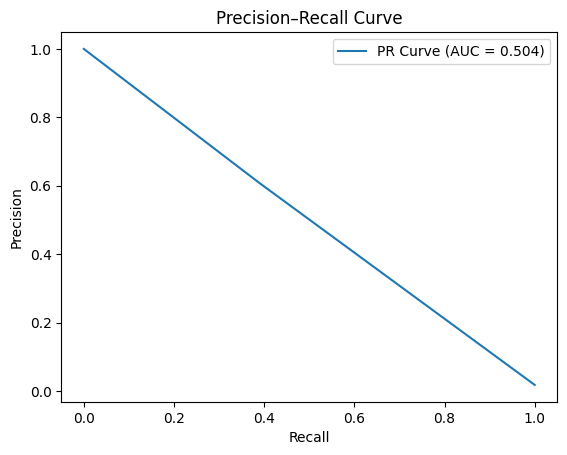

In [53]:
plt.plot(recall, precision, label=f'PR Curve (AUC = {pr_auc:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision–Recall Curve')
plt.legend()
plt.show()

In [55]:
##This shows model perform no best than rough guess work
best_thresh = threshold[np.argmax(f1)]
print("Best threshold:", best_thresh)

Best threshold: 1


In [62]:
tpr, fpr, probab = m.roc_curve(y_test,y_pred_probab)
ac = m.roc_auc_score(y_test,y_pred_probab)

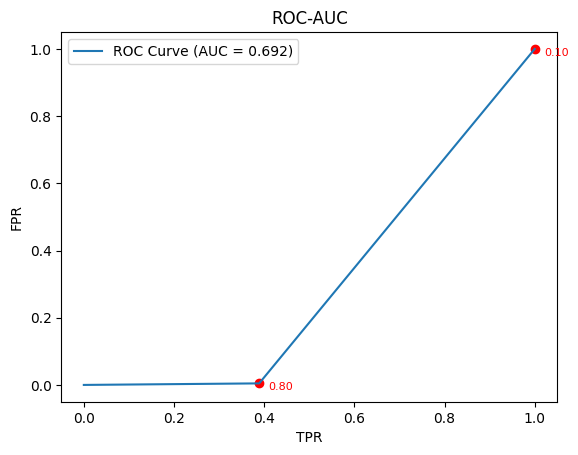

In [69]:
plt.plot(fpr,tpr, label=f'ROC Curve (AUC = {ac:.3f})')
important_thresholds = [0.1, 0.8]
for thr in important_thresholds:
    #returns the index of the smallest difference — i.e., where the threshold value is closest to your target.
    idx = np.argmin(np.abs(probab - thr))
    plt.scatter(fpr[idx], tpr[idx], color='red')
    ##+0.2 to show the text
    plt.text(fpr[idx]+0.02, tpr[idx]-0.02, f"{thr:.2f}", color='red', fontsize=8)
plt.xlabel('TPR')
plt.ylabel('FPR')
plt.title('ROC-AUC')
plt.legend()
plt.show()

In [ ]:
##Test data too small to begin with